In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import os

pd.set_option('display.width', 160)
OUT_DIR = 'outputs'; FIG_DIR = 'outputs/figures'
os.makedirs(FIG_DIR, exist_ok=True)

d = pd.read_parquet(f'{OUT_DIR}/analytic_dataset.parquet')
T = d['T'].values
print('Jeu analytique chargé :', d.shape)

Jeu analytique chargé : (654, 24)


In [2]:
CONF = ['age', 'mariee', 'revenu_ord', 'instruction_ord', 'agri_elevage',
        'nb_grossesses', 'nb_enfants', 'antecedent_complication',
        'accouchement_dystocique', 'wealth_index']

Xps = pd.concat([d[CONF], pd.get_dummies(d['site'], prefix='site', drop_first=True)], axis=1).astype(float)
Xz  = StandardScaler().fit_transform(Xps)

model = LogisticRegression(penalty='l2', C=1.0, max_iter=5000, solver='lbfgs').fit(Xz, T)
e = model.predict_proba(Xz)[:, 1]
d['propensity'] = e
print('Score de propension estimé (min=%.3f, moyenne=%.3f, max=%.3f)' % (e.min(), e.mean(), e.max()))

Score de propension estimé (min=0.004, moyenne=0.503, max=0.951)


In [3]:
print('Distribution du score de propension par groupe :')
for g, lab in [(1, 'CAS    '), (0, 'TÉMOINS')]:
    s = pd.Series(e[T == g])
    print('  %s min=%.3f  q25=%.3f  méd=%.3f  q75=%.3f  max=%.3f' %
          (lab, s.min(), s.quantile(.25), s.median(), s.quantile(.75), s.max()))
print()
print('Score de propension moyen par site :')
print(pd.Series(e, index=d.index).groupby(d['site']).mean().round(3).to_string())

out_overlap = int(((e < 0.1) | (e > 0.9)).sum())
print('\nFemmes hors zone de chevauchement [0.1 ; 0.9] : %d (%.0f%%)' %
      (out_overlap, 100 * out_overlap / len(d)))

Distribution du score de propension par groupe :
  CAS     min=0.325  q25=0.600  méd=0.690  q75=0.816  max=0.951
  TÉMOINS min=0.004  q25=0.011  méd=0.030  q75=0.600  max=0.892

Score de propension moyen par site :
site
Fatick         0.014
Foundiougne    0.593
Koungheul      0.805

Femmes hors zone de chevauchement [0.1 ; 0.9] : 177 (27%)


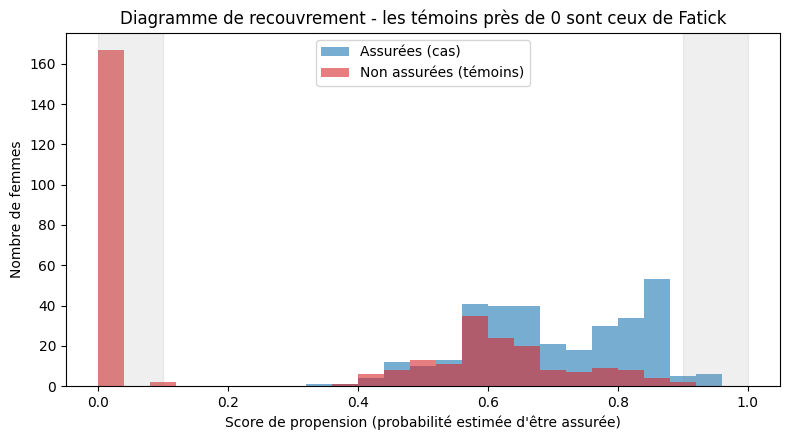

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 1, 26)
ax.hist(e[T == 1], bins=bins, alpha=0.6, label='Assurées (cas)', color='#1f77b4')
ax.hist(e[T == 0], bins=bins, alpha=0.6, label='Non assurées (témoins)', color='#d62728')
ax.axvspan(0, 0.1, color='grey', alpha=0.12)
ax.axvspan(0.9, 1, color='grey', alpha=0.12)
ax.set_xlabel('Score de propension (probabilité estimée d\'être assurée)')
ax.set_ylabel('Nombre de femmes')
ax.set_title('Diagramme de recouvrement - les témoins près de 0 sont ceux de Fatick')
ax.legend(); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/recouvrement.png', dpi=150)
plt.show()

In [5]:
w = np.where(T == 1, 1 - e, e)
d['overlap_weight'] = w

print('Masse des poids par site :')
wt = pd.DataFrame({'site': d['site'], 'masse_poids': w}).groupby('site')['masse_poids'].sum()
wt = pd.DataFrame({'masse_poids': wt.round(1), 'part_%': (100 * wt / wt.sum()).round(1)})
print(wt.to_string())

def ess(x):   # taille d'échantillon effective : (Σw)² / Σw²
    return (x.sum() ** 2) / (np.square(x).sum())
print('\nTaille effective - cas : %.0f / %d  |  témoins : %.0f / %d' %
      (ess(w[T == 1]), (T == 1).sum(), ess(w[T == 0]), (T == 0).sum()))

Masse des poids par site :
             masse_poids  part_%
site                            
Fatick               2.3     1.2
Foundiougne        141.4    71.1
Koungheul           55.1    27.7

Taille effective - cas : 279 / 329  |  témoins : 158 / 325


In [6]:
def smd_unw(v):
    x = pd.to_numeric(d[v], errors='coerce'); a, b = x[T == 1], x[T == 0]
    sp = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return np.nan if sp == 0 else (a.mean() - b.mean()) / sp

def smd_w(v):
    x = pd.to_numeric(d[v], errors='coerce').values
    ma = np.average(x[T == 1], weights=w[T == 1]); mb = np.average(x[T == 0], weights=w[T == 0])
    sp = np.sqrt((x[T == 1].var(ddof=1) + x[T == 0].var(ddof=1)) / 2)
    return np.nan if sp == 0 else (ma - mb) / sp

bal = pd.DataFrame({'SMD_avant': [smd_unw(v) for v in CONF],
                    'SMD_apres': [smd_w(v)   for v in CONF]}, index=CONF).round(3)
print(bal.to_string())
print('\n|SMD| max  avant : %.3f  -  apres : %.3f' %
      (bal['SMD_avant'].abs().max(), bal['SMD_apres'].abs().max()))

                         SMD_avant  SMD_apres
age                         -0.226     -0.001
mariee                       0.039     -0.002
revenu_ord                  -0.385      0.002
instruction_ord             -0.623     -0.003
agri_elevage                 0.077     -0.000
nb_grossesses                0.098      0.001
nb_enfants                   0.046     -0.001
antecedent_complication      0.158      0.002
accouchement_dystocique      0.082     -0.001
wealth_index                -0.476     -0.002

|SMD| max  avant : 0.623  -  apres : 0.003


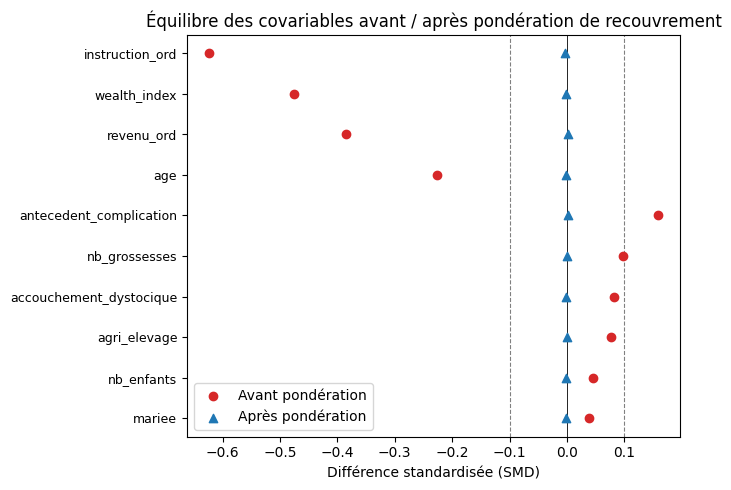

In [7]:
order = bal['SMD_avant'].abs().sort_values().index
fig, ax = plt.subplots(figsize=(7, 5))
yy = np.arange(len(order))
ax.scatter(bal.loc[order, 'SMD_avant'], yy, color='#d62728', label='Avant pondération', zorder=3)
ax.scatter(bal.loc[order, 'SMD_apres'], yy, color='#1f77b4', marker='^', label='Après pondération', zorder=3)
for x0 in (-0.1, 0.1):
    ax.axvline(x0, color='grey', ls='--', lw=0.8)
ax.axvline(0, color='k', lw=0.6)
ax.set_yticks(yy); ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel('Différence standardisée (SMD)')
ax.set_title('Équilibre des covariables avant / après pondération de recouvrement')
ax.legend(); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/love_plot.png', dpi=150)
plt.show()

In [8]:
d.to_csv(f'{OUT_DIR}/analytic_with_weights.csv', index=False, encoding='utf-8-sig')
d.to_parquet(f'{OUT_DIR}/analytic_with_weights.parquet')
bal.to_csv(f'{OUT_DIR}/balance_avant_apres.csv', encoding='utf-8-sig')
print('Sauvegardé : analytic_with_weights.csv/.parquet, balance_avant_apres.csv')
print('Figures : recouvrement.png, love_plot.png')

Sauvegardé : analytic_with_weights.csv/.parquet, balance_avant_apres.csv
Figures : recouvrement.png, love_plot.png
